#### https://github.com/anirvandecodes/Spark-Structured-Streaming-with-Kafka/tree/main

## Kafka Streaming Notes

Output Modes

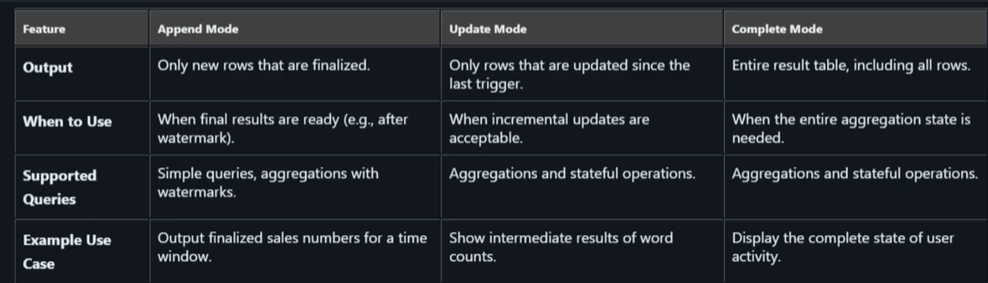

# List of Sinks in Spark Structured Streaming
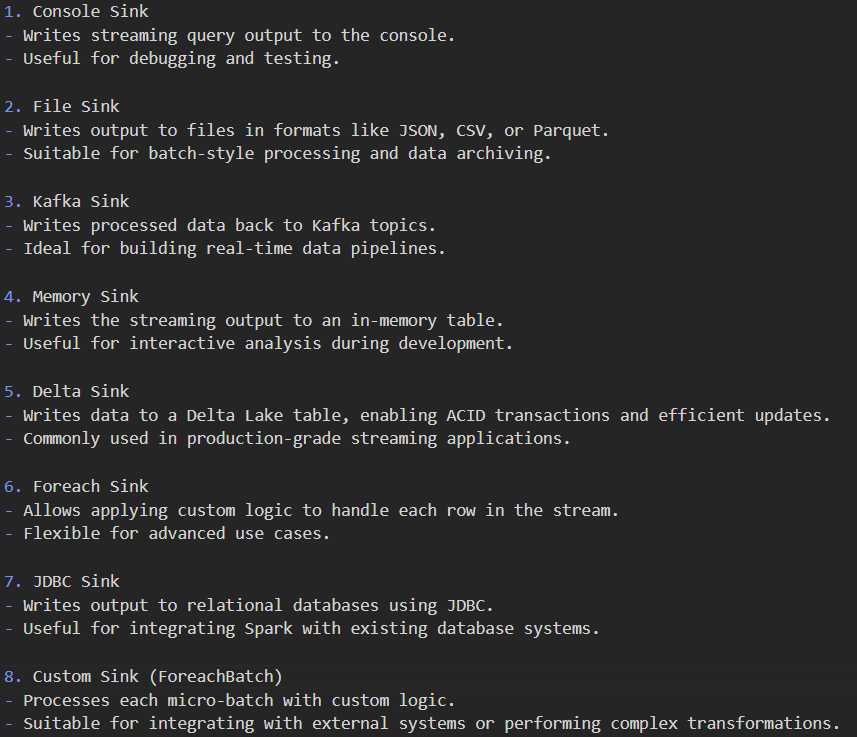

## Tumbling Window Aggregation

- A tumbling window is a fixed-size, non-overlapping window. It is useful for aggregating data within a time period, such as counting the number of
items sold in each hour.

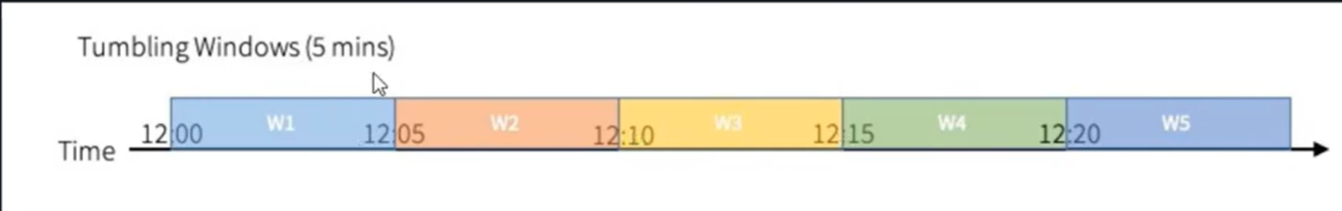

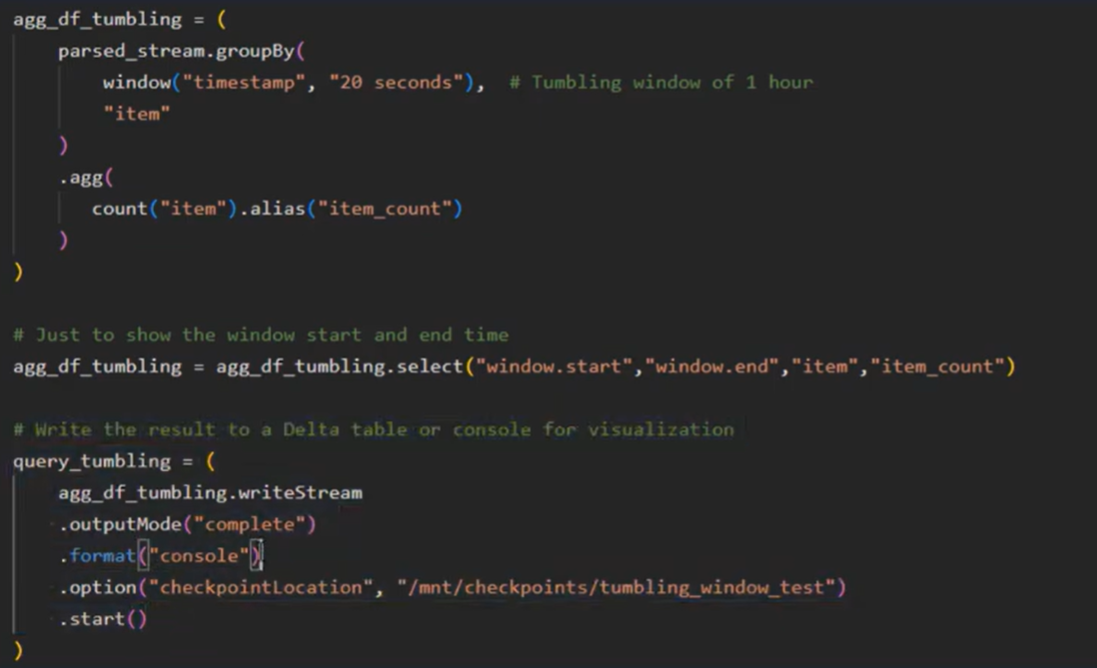

## Sliding window

- It aggregates data over a moving time window. For example, you can calculate the sum of the quantity of items sold in the past 15 minutes, but the slides as time progresses.

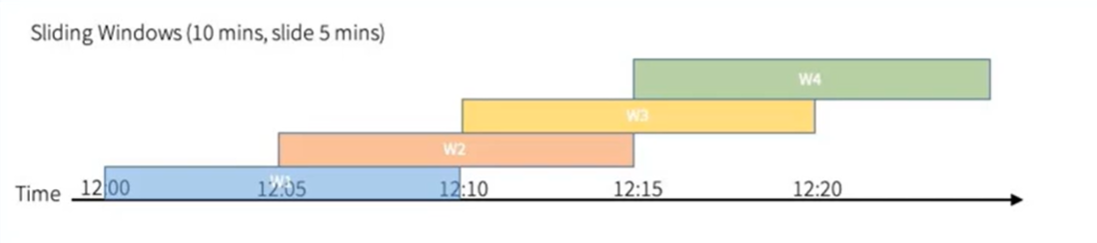

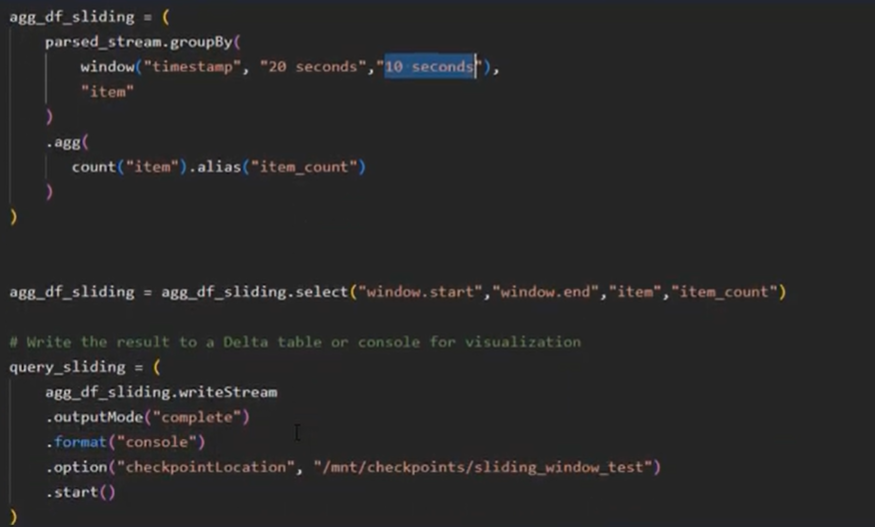

## WaterMark for Late Arriving Data (Event-Time Processing)
 - When working with event-time data, it’s common to deal with late-arriving data. In Spark, you can handle late data by using watermarks.

 ### Causes of Late-Arriving Data in Kafka
 - 1. **Network and Producer Delays**: High network latency, resource contention, or retries in the producer can delay message delivery.  
 - 2. **Broker Overload**: Overloaded Kafka brokers or slow replication can introduce processing delays.  
 -  3. **Upstream Delays**: Latency in upstream systems or IoT devices can make events arrive late in Kafka.


In [ ]:
from pyspark.sql.functions import window, count

# Add watermark and perform windowed aggregation
agg_df_tumbling = (
    parsed_stream
    .withWatermark("timestamp", "30 seconds")  # Add watermark for late data handling
    .groupBy(
        window("timestamp", "20 seconds"),  # Group data into 20-second windows
        "item"
    )
    .agg(
        count("item").alias("item_count")  # Aggregate the count of items
    )
)

# Select specific columns for output
agg_df_tumbling = agg_df_tumbling.select(
    "window.start",
    "window.end",
    "item",
    "item_count"
)

# Write to memory with checkpointing for fault tolerance
query = agg_df_tumbling.writeStream \
    .outputMode("append") \
    .format("memory") \
    .queryName("tumbling_window_query") \
    .option("checkpointLocation", "/mnt/checkpoints/late_arriving_data_demo") \
    .start()